In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
import glob
import os
import warnings
warnings.filterwarnings('ignore')

# Set up matplotlib for jupyter
%matplotlib inline
plt.style.use('default')

In [2]:
results_paths = 'results/split_spatialL_*_loc_locenc'
admin_level = 'ADM2NAME'
min_samples = 1

In [ ]:
def load_all_fold_predictions(results_paths):
    """Load and combine predictions from all folds"""
    
    folders = glob.glob(results_paths)
    folders.sort()
    
    print(f"Found {len(folders)} result folders:")
    for folder in folders:
        print(f"  {folder}")
    
    all_predictions = []
    
    for folder in folders:
        # Extract fold number
        fold_num = None
        for part in folder.split('_'):
            if part.isdigit():
                fold_num = int(part)
                break
        
        # Load test predictions
        test_file = f"{folder}/test_predictions_with_metadata.csv"
        
        if os.path.exists(test_file):
            try:
                df = pd.read_csv(test_file)
                df['fold'] = fold_num
                all_predictions.append(df)
                print(f" Loaded fold {fold_num}: {len(df)} predictions")
            except Exception as e:
                print(f" Error loading {test_file}: {e}")
        else:
            print(f"  File not found: {test_file}")
    
    if all_predictions:
        combined_df = pd.concat(all_predictions, ignore_index=True)
        print(f"\n Combined dataset: {len(combined_df)} total predictions from {len(all_predictions)} folds")
        return combined_df
    else:
        print(" No predictions found!")
        return None

In [20]:
# Load the data
all_predictions = load_all_fold_predictions(results_paths)
all_predictions['are'] = (all_predictions['error'] / all_predictions['target'])
all_predictions

Found 5 result folders:
  results/split_spatialL_1_loc_locenc
  results/split_spatialL_2_loc_locenc
  results/split_spatialL_3_loc_locenc
  results/split_spatialL_4_loc_locenc
  results/split_spatialL_5_loc_locenc
 Loaded fold 1: 2713 predictions
 Loaded fold 2: 2630 predictions
 Loaded fold 3: 2647 predictions
 Loaded fold 4: 2670 predictions
 Loaded fold 5: 2655 predictions

 Combined dataset: 13315 total predictions from 5 folds


,target,prediction,error,split,CENTROID_ID,LATNUM,LONGNUM,fold,are
0,0.987952,0.792157,0.195795,test,MD202100000405,-14.666128,47.736276,1,0.198182
1,0.560976,0.641648,0.080673,test,BU201600000223,-2.894248,29.103441,1,0.143808
2,1.000000,0.727584,0.272416,test,UG201600000111,0.635475,31.557086,1,0.272416
3,1.000000,0.695016,0.304984,test,MZ201100000248,-14.762143,32.581608,1,0.304984
4,0.876712,0.807051,0.069662,test,UG201600000411,2.649540,32.430983,1,0.079458
...,...,...,...,...,...,...,...,...,...
13310,0.527778,0.491412,0.036366,test,KE202200001620,-0.557853,34.964889,5,0.068903
13311,0.812500,0.548216,0.264284,test,KE202200000995,0.170732,34.949714,5,0.325273
13312,0.142857,0.428356,0.285499,test,AO201500000267,-8.924989,13.332303,5,1.998492
13313,0.085106,0.134395,0.049289,test,RW201900000454,-1.969361,30.050133,5,0.579142


<Axes: >

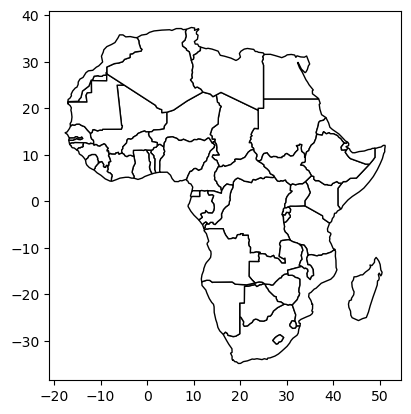

In [21]:
import geopandas as gpd

# Use built-in Natural Earth data
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
africa_gdf = world[world['continent'] == 'Africa']

# Plot the Africa boundary as a base layer
africa_gdf.plot( color='white', edgecolor='black')

In [26]:
import geopandas as gpd
from shapely.geometry import Point
# Convert the DataFrame into a GeoDataFrame
def append_geo(df):
    gdf_points = gpd.GeoDataFrame(
        df, 
        geometry=gpd.points_from_xy(df['LONGNUM'], df['LATNUM']),
        crs="EPSG:4326"
    )

    # Load the admin 2 boundaries GeoDataFrame
    # Ensure that the file includes polygons for admin 2 subdivisions in Africa
    admin2_gdf = gpd.read_file('output_shp/merged_adm2.shp')
    print(admin2_gdf.head())
    print(admin2_gdf.crs)

    # Project both GeoDataFrames to a common CRS if necessary
    if admin2_gdf.crs != gdf_points.crs:
        admin2_gdf = admin2_gdf.to_crs(gdf_points.crs)

    # Perform the spatial join
    # 'how="left"' means all points will remain, gaining admin 2 data if they fall within a polygon
    joined_gdf = gpd.sjoin(gdf_points, admin2_gdf, how="left", predicate="within")

    # Suppose the admin 2 name column in the polygons is named "admin2_name"
    return joined_gdf

In [27]:
test_gdf = append_geo(all_predictions)

   ADM2_EN ADM2_PCODE  ADM1_EN ADM1_PCODE   ADM0_EN ADM0_PCODE  \
0    Afder     ET0508   Somali       ET05  Ethiopia         ET   
1  Agnewak     ET1202  Gambela       ET12  Ethiopia         ET   
2     Alle     ET0712     SNNP       ET07  Ethiopia         ET   
3    Amaro     ET0721     SNNP       ET07  Ethiopia         ET   
4     Arsi     ET0408   Oromia       ET04  Ethiopia         ET   

                                            geometry  
0  POLYGON ((42.02878 6.61478, 42.03432 6.61348, ...  
1  POLYGON ((34.82643 8.26194, 34.85509 8.25065, ...  
2  POLYGON ((37.12605 5.72774, 37.12655 5.72627, ...  
3  POLYGON ((37.85677 5.99870, 37.86554 5.98663, ...  
4  POLYGON ((39.92013 8.70959, 39.92602 8.70937, ...  
epsg:4326


In [28]:
test_gdf

,target,prediction,error,split,CENTROID_ID,LATNUM,LONGNUM,fold,are,geometry,index_right,ADM2_EN,ADM2_PCODE,ADM1_EN,ADM1_PCODE,ADM0_EN,ADM0_PCODE
0,0.987952,0.792157,0.195795,test,MD202100000405,-14.666128,47.736276,1,0.198182,POINT (47.73628 -14.66613),1580.0,Analalava,MG42411,Sofia,MG42,Madagascar,MG
1,0.560976,0.641648,0.080673,test,BU201600000223,-2.894248,29.103441,1,0.143808,POINT (29.10344 -2.89425),760.0,Rugombo,BDI005006,Cibitoke,BDI005,Burundi,BD
2,1.000000,0.727584,0.272416,test,UG201600000111,0.635475,31.557086,1,0.272416,POINT (31.55709 0.63548),1479.0,Mubende,UG1020,Central,UG1,Uganda,UG
3,1.000000,0.695016,0.304984,test,MZ201100000248,-14.762143,32.581608,1,0.304984,POINT (32.58161 -14.76214),899.0,Chifunde,MZ1004,Tete,MZ10,Mozambique,MZ
4,0.876712,0.807051,0.069662,test,UG201600000411,2.649540,32.430983,1,0.079458,POINT (32.43098 2.64954),1050.0,Omoro,UG3094,Northern,UG3,Uganda,UG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13310,0.527778,0.491412,0.036366,test,KE202200001620,-0.557853,34.964889,5,0.068903,POINT (34.96489 -0.55785),111.0,Borabu,KE046273,Nyamira,KE046,Kenya,KE
13311,0.812500,0.548216,0.264284,test,KE202200000995,0.170732,34.949714,5,0.325273,POINT (34.94971 0.17073),134.0,Emgwen,KE029155,Nandi,KE029,Kenya,KE
13312,0.142857,0.428356,0.285499,test,AO201500000267,-8.924989,13.332303,5,1.998492,POINT (13.33230 -8.92499),733.0,Viana,AO11100,Luanda,AO11,Angola,AO
13313,0.085106,0.134395,0.049289,test,RW201900000454,-1.969361,30.050133,5,0.579142,POINT (30.05013 -1.96936),469.0,Nyarugenge,RW11,Kigali City,RW1,Rwanda,RW


In [30]:
# aggregated by country + admin2 and average by error
grouped_df = test_gdf.groupby(['ADM0_EN', 'ADM2_EN'])[['target','prediction','error','are','LATNUM','LONGNUM']].mean().reset_index()
grouped_df['admin2_error'] = (grouped_df['target'] - grouped_df['prediction']).abs()
grouped_df

,ADM0_EN,ADM2_EN,target,prediction,error,are,LATNUM,LONGNUM,admin2_error
0,Angola,Alto Zambeze,0.836667,0.849385,0.108547,0.129840,-11.506114,23.310668,0.012719
1,Angola,Ambaca,0.300000,0.501179,0.201179,0.670596,-8.201536,15.379319,0.201179
2,Angola,Amboim (Gabela),1.000000,1.039919,0.039919,0.039919,-10.818325,14.419114,0.039919
3,Angola,Ambriz,0.755102,0.670135,0.084967,0.112524,-7.852511,13.721998,0.084967
4,Angola,Andulo,0.930556,0.838184,0.092372,0.096337,-11.319785,16.414856,0.092372
...,...,...,...,...,...,...,...,...,...
1518,Zimbabwe,Victoria Falls,0.241120,0.378882,0.206982,NaN,-17.939067,25.829438,0.137763
1519,Zimbabwe,Zaka,0.741813,0.635966,0.275548,1.143027,-20.422966,31.469767,0.105847
1520,Zimbabwe,Zvimba,0.687385,0.665190,0.188814,0.296394,-17.537513,30.434495,0.022195
1521,Zimbabwe,Zvishavane,0.357143,0.501201,0.144058,0.403362,-20.285909,30.061360,0.144058


In [35]:
points_gdf = gpd.GeoDataFrame(
    grouped_df,
    geometry=gpd.points_from_xy(grouped_df['LONGNUM'], grouped_df['LATNUM']),
    crs="EPSG:4326"
)
admin2_gdf  = gpd.read_file('output_shp/merged_adm2.shp')
# 3. Spatial join to find which admin 2 each point belongs to
joined_gdf = gpd.sjoin(points_gdf, admin2_gdf, how="left", predicate="within")

# Assume admin 2 name column in the shapefile is 'ADM2_NAME'
# Now joined_gdf contains 'ADM2_NAME' for each point along with 'value'.

# 4. Aggregate values by admin 2 region if multiple points belong to the same region
joined_gdf['ADM2_EN'] = joined_gdf['ADM2_EN_left']

# Merge aggregated data back into the admin2_gdf
choropleth_gdf = admin2_gdf.merge(joined_gdf, on='ADM2_PCODE', how='right')
# choropleth_gdf = joined_gdf
# remove nan from choropleth_gdf
choropleth_gdf = choropleth_gdf.dropna(subset=['are'])
# remove inf from choropleth_gdf
choropleth_gdf = choropleth_gdf[~choropleth_gdf['are'].isin([float('inf')])]
choropleth_gdf.head()


,ADM2_EN_x,ADM2_PCODE,ADM1_EN_x,ADM1_PCODE_x,ADM0_EN,ADM0_PCODE_x,geometry_x,ADM0_EN_left,ADM2_EN_left,target,...,LONGNUM,admin2_error,geometry_y,index_right,ADM2_EN_right,ADM1_EN_y,ADM1_PCODE_y,ADM0_EN_right,ADM0_PCODE_y,ADM2_EN_y
0,Alto Zambeze,AO15128,Moxico,AO15,Angola,AO,"POLYGON ((24.01637 -11.01829, 24.01387 -11.030...",Angola,Alto Zambeze,0.836667,...,23.310668,0.012719,POINT (23.31067 -11.50611),1146.0,Alto Zambeze,Moxico,AO15,Angola,AO,Alto Zambeze
1,Ambaca,AO06037,Cuanza Norte,AO06,Angola,AO,"POLYGON ((15.49116 -8.05464, 15.49820 -8.05608...",Angola,Ambaca,0.300000,...,15.379319,0.201179,POINT (15.37932 -8.20154),1567.0,Ambaca,Cuanza Norte,AO06,Angola,AO,Ambaca
2,Amboim (Gabela),AO07050,Cuanza Sul,AO07,Angola,AO,"POLYGON ((14.56600 -10.76659, 14.56905 -10.789...",Angola,Amboim (Gabela),1.000000,...,14.419114,0.039919,POINT (14.41911 -10.81832),875.0,Amboim (Gabela),Cuanza Sul,AO07,Angola,AO,Amboim (Gabela)
3,Ambriz,AO01001,Bengo,AO01,Angola,AO,"POLYGON ((13.84173 -7.65877, 13.84311 -7.68157...",Angola,Ambriz,0.755102,...,13.721998,0.084967,POINT (13.72200 -7.85251),1275.0,Ambriz,Bengo,AO01,Angola,AO,Ambriz
4,Andulo,AO03015,Bié,AO03,Angola,AO,"POLYGON ((16.81091 -10.99174, 16.82783 -11.016...",Angola,Andulo,0.930556,...,16.414856,0.092372,POINT (16.41486 -11.31978),1456.0,Andulo,Bié,AO03,Angola,AO,Andulo


<Axes: >

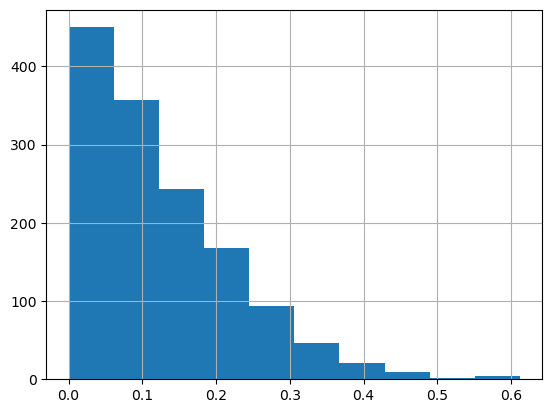

In [36]:
choropleth_gdf.admin2_error.hist()

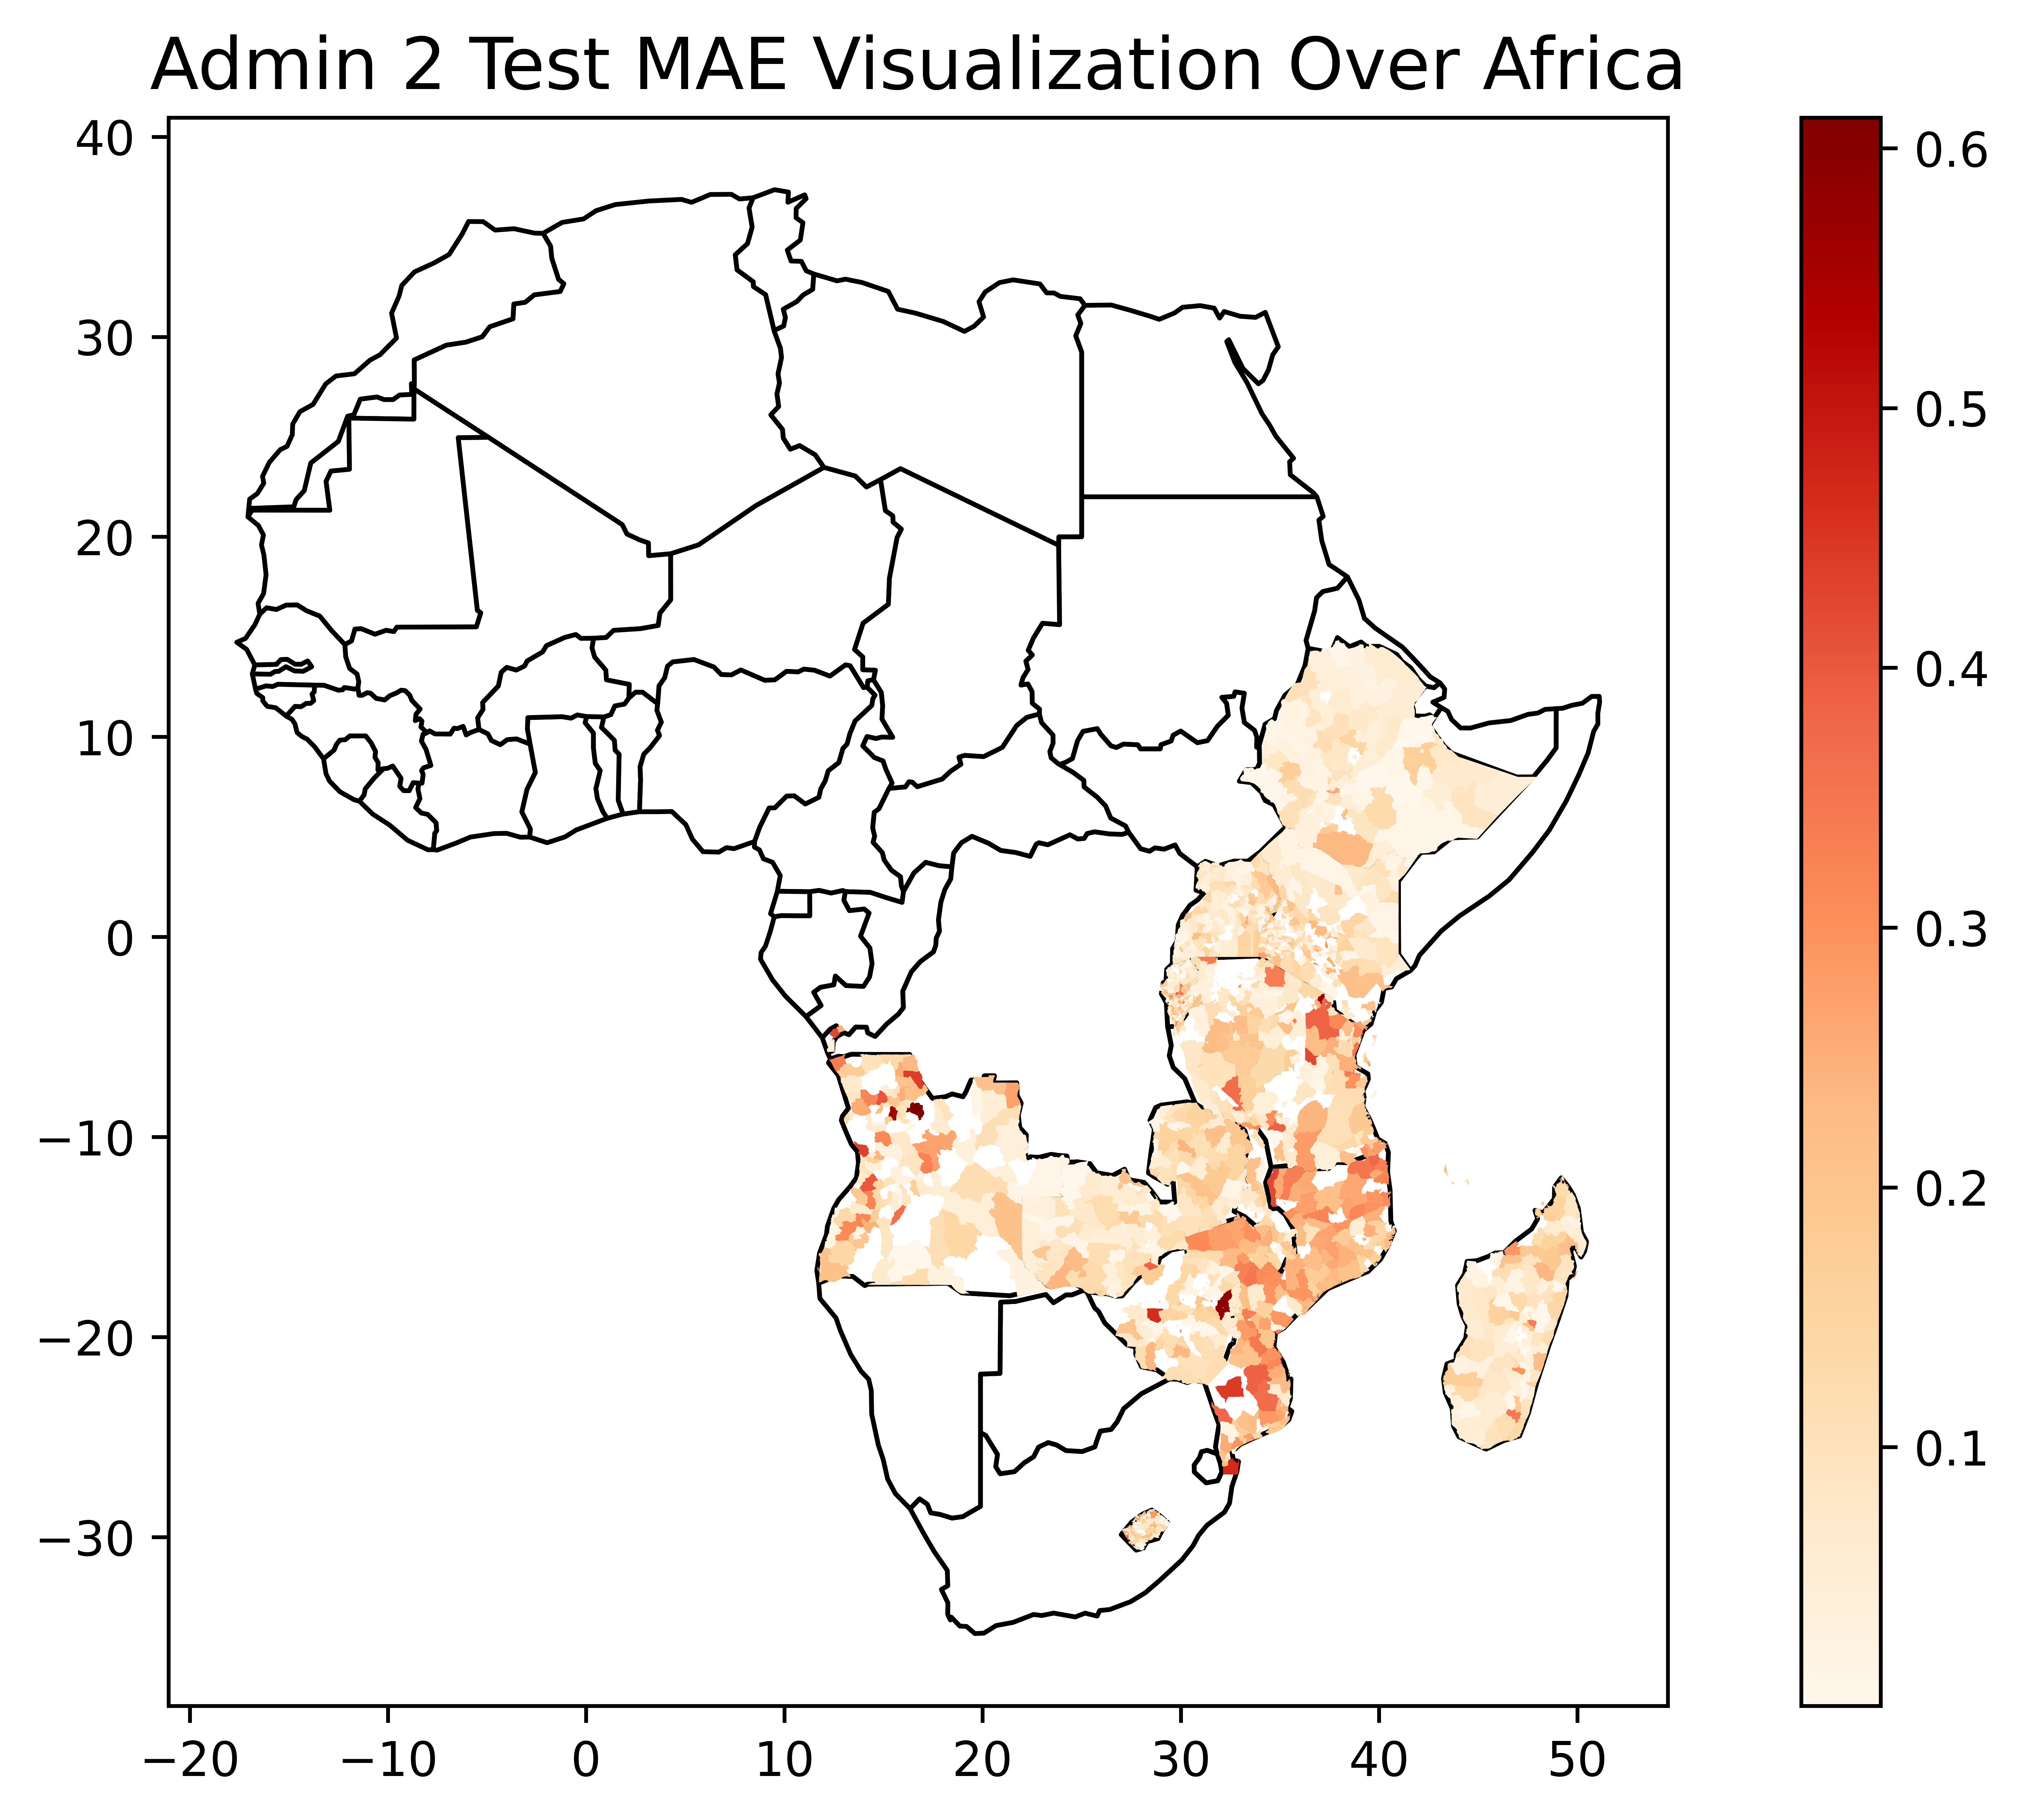

In [37]:
choropleth_gdf = gpd.GeoDataFrame(choropleth_gdf, geometry='geometry_x')


# Optionally set a title
import geopandas as gpd
import matplotlib.pyplot as plt

# Load Africa boundary shapefile (this could be a countries-level shapefile)
# africa_gdf = gpd.read_file('afr_adm0/afr_g2014_2013_0.shp')

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
africa_gdf = world[world['continent'] == 'Africa']

# Ensure all GeoDataFrames are in the same CRS
if africa_gdf.crs != choropleth_gdf.crs:
    africa_gdf = africa_gdf.to_crs(choropleth_gdf.crs)

fig, ax = plt.subplots(figsize=(10, 6), dpi=1000)

# Plot the Africa boundary as a base layer
africa_gdf.plot(ax=ax, color='white', edgecolor='black')

# Plot the admin 2 level choropleth on top # adjust line width
choropleth_gdf.plot(column='admin2_error', cmap='OrRd', legend=True, ax=ax, linewidth=0.5)

ax.set_title("Admin 2 Test MAE Visualization Over Africa", fontsize=15)
plt.show()